# TS6

In [78]:
import numpy as np
import matplotlib.pyplot as plt
import scipy 
import scipy.io as sio
from scipy.io.wavfile import write

## Lectura de señales

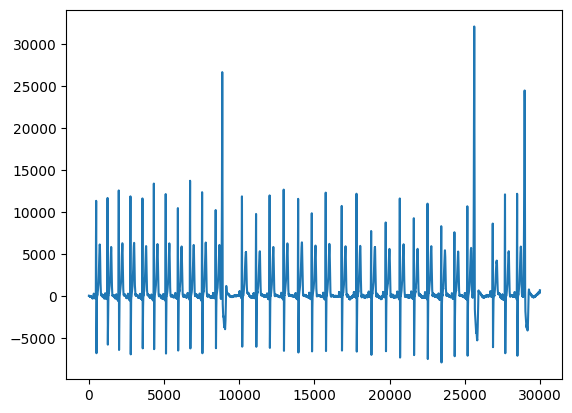

In [79]:
fs_ecg = 1000 # Hz

ecg_one_lead = np.load('ecg_sin_ruido.npy')

plt.figure()
plt.plot(ecg_one_lead)

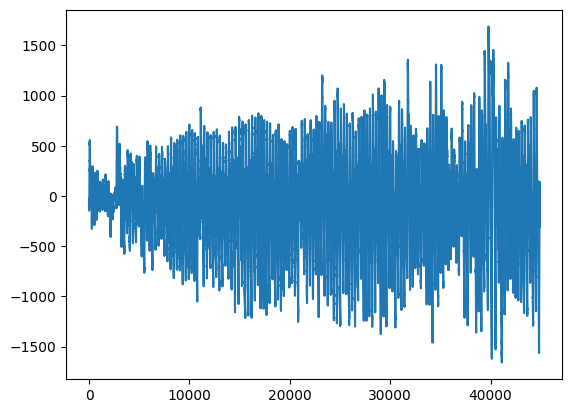

In [80]:
####################################
# Lectura de pletismografía (PPG)  #
####################################

fs_ppg = 400 # Hz

ppg = np.load('ppg_sin_ruido.npy')

plt.figure()
plt.plot(ppg)


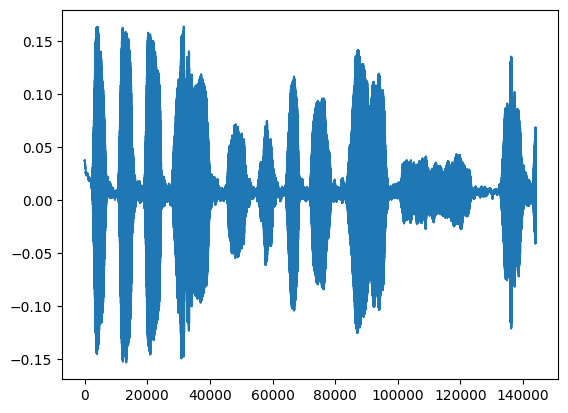

In [81]:
fs_audio, wav_data = sio.wavfile.read('la cucaracha.wav')
# fs_audio, wav_data = sio.wavfile.read('prueba psd.wav')
# fs_audio, wav_data = sio.wavfile.read('silbido.wav')

plt.figure()
plt.plot(wav_data)

## Estimacion Espectral del ECG usando Metodo de Welch

### Busqueda del "K ideal" del ECG

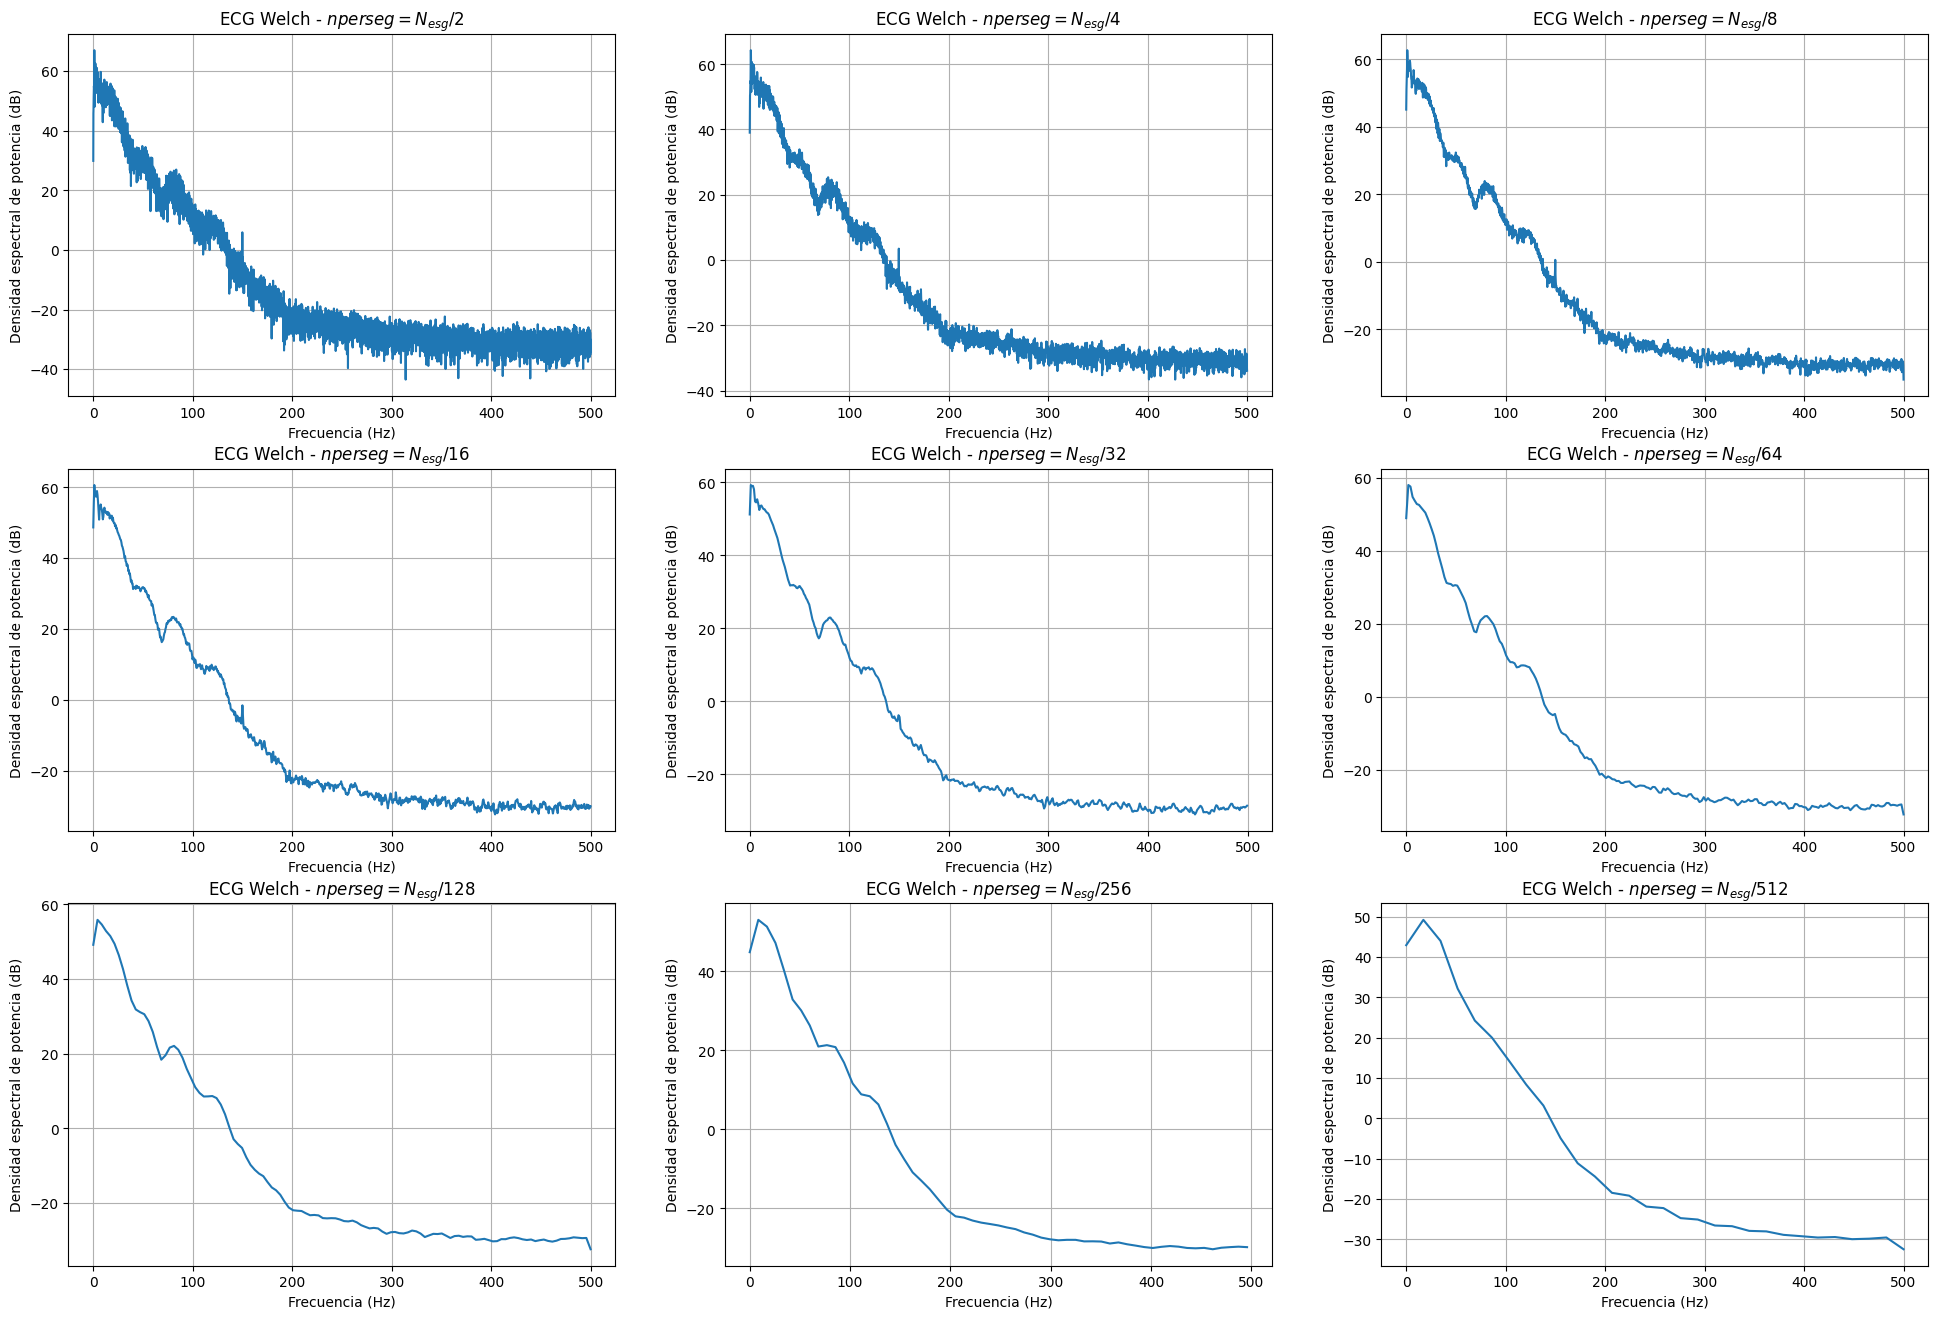

In [82]:
# Estimacion espectral mediante WELCH

N_esg = len(ecg_one_lead)

nombres_nperseg = ['N_{esg}/2', 'N_{esg}/4', 'N_{esg}/8', 'N_{esg}/16', 'N_{esg}/32', 'N_{esg}/64', 'N_{esg}/128', 'N_{esg}/256', 'N_{esg}/512']
vector_nperseg = [N_esg / 2, N_esg / 4, N_esg / 8, N_esg / 16, N_esg / 32, N_esg / 64, N_esg / 128, N_esg / 256, N_esg / 512]

ecg_welch = []

for nperseg in vector_nperseg:
    welch_result = scipy.signal.welch(ecg_one_lead, fs=fs_ecg, window='hann_periodic', nperseg=nperseg, noverlap=None, nfft=None, detrend='constant', return_onesided=True, scaling='density', axis=-1, average='mean')
    ecg_welch.append(welch_result)

plt.figure(figsize=(24, 16))
for i, nperseg in enumerate(vector_nperseg):
    plt.subplot(3, 3, i+1)
    signal_db = 10 * np.log10(ecg_welch[i][1])
    plt.plot(ecg_welch[i][0], signal_db)
    plt.title(fr'ECG Welch - $nperseg={nombres_nperseg[i]}$')
    plt.xlabel('Frecuencia (Hz)')
    plt.ylabel('Densidad espectral de potencia (dB)')
    plt.grid()

Vemos que lo ideal esta entre K=4 y k=16, graficamos los espectros entre esos valores haciendo zoom en donde se concentra la energia.:

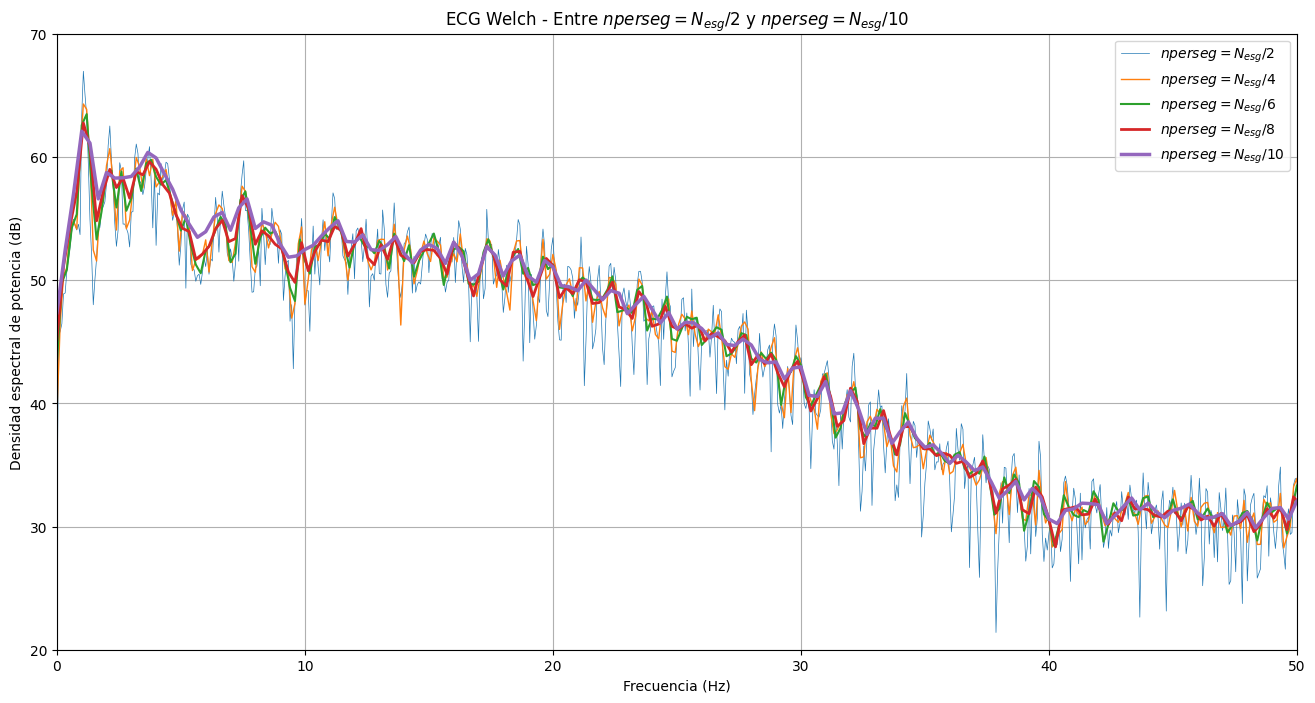

In [83]:
nombres_nperseg = ['N_{esg}/2', 'N_{esg}/4', 'N_{esg}/6', 'N_{esg}/8', 'N_{esg}/10']
vector_nperseg = [N_esg / 2, N_esg / 4, N_esg / 6, N_esg / 8, N_esg / 10]

ecg_welch = []

for nperseg in vector_nperseg:
    welch_result = scipy.signal.welch(ecg_one_lead, fs=fs_ecg, window='hann_periodic', nperseg=nperseg, noverlap=None, nfft=None, detrend='constant', return_onesided=True, scaling='density', axis=-1, average='mean')
    ecg_welch.append(welch_result)

plt.figure(figsize=(16, 8))
for i, nperseg in enumerate(vector_nperseg):
    signal_db = 10 * np.log10(ecg_welch[i][1])
    plt.plot(ecg_welch[i][0], signal_db, label=fr'$nperseg={nombres_nperseg[i]}$', linewidth=(i+1)*0.5)
plt.title(fr'ECG Welch - Entre $nperseg={nombres_nperseg[0]}$ y $nperseg={nombres_nperseg[-1]}$')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Densidad espectral de potencia (dB)')
plt.xlim(0, 50)
plt.ylim(20, 70)
plt.legend()
plt.grid()


Definimos K = 8:

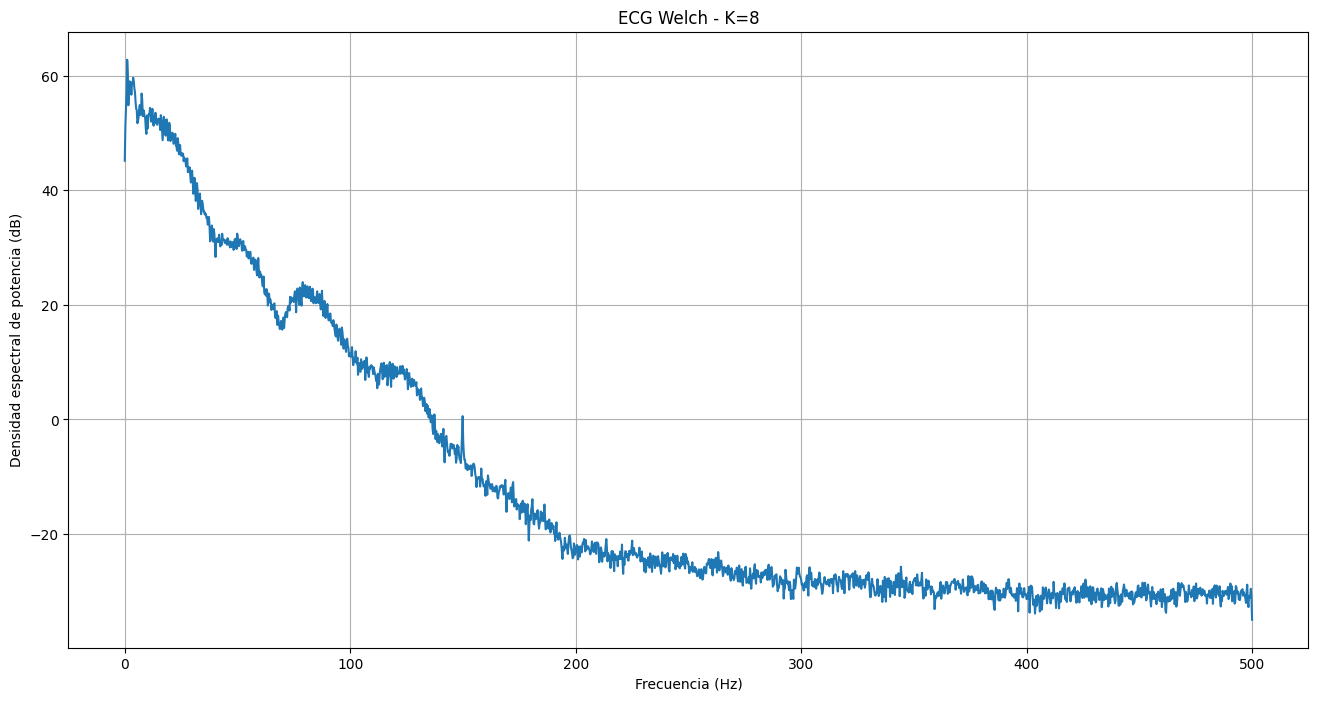

In [84]:
nperseg = N_esg / 8
ecg_welch = scipy.signal.welch(ecg_one_lead, fs=fs_ecg, window='hann_periodic', nperseg=nperseg, noverlap=None, nfft=None, detrend='constant', return_onesided=True, scaling='density', axis=-1, average='mean')
plt.figure(figsize=(16, 8))
signal_db = 10 * np.log10(ecg_welch[1])
plt.plot(ecg_welch[0], signal_db)
plt.title(f'ECG Welch - K=8')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Densidad espectral de potencia (dB)')
plt.grid()

## Estimacion Espectral del ECG usando Metodo de Blackman - Tukey

Funcion (modificada) para calcularlo del repositorio pdsworkbench:

(30000, 1)
(30000, 1)
(30000, 1)


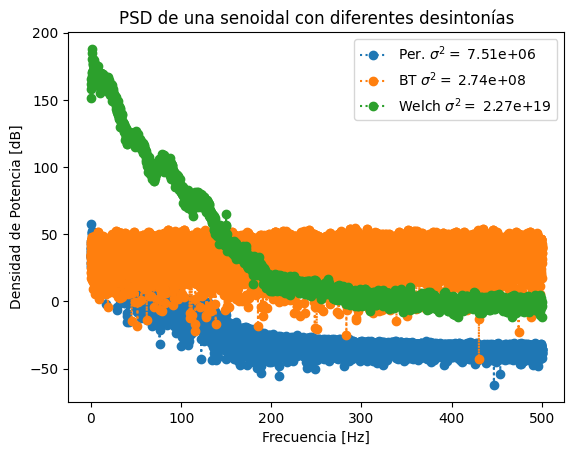

In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Wed Sep  8 16:56:51 2021

PDS TS 5


@author: mariano
"""

#%% Configuración e inicio de la simulación

import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sig


def blackman_tukey(x,  M = None, window = 'blackman'):    
    
    # N = len(x)
    x_z = x.shape
    
    N = np.max(x_z)
    
    if M is None:
        M = N//5
    
    r_len = 2*M-1

    # hay que aplanar los arrays por np.correlate.
    # usaremos el modo same que simplifica el tratamiento
    # de la autocorr
    xx = x.ravel()[:r_len];

    r = np.correlate(xx, xx, mode='same') / r_len

    Px = np.abs(np.fft.fft(r * sig.get_window(window, r_len), n = N) )

    Px = Px.reshape(x_z)

    return Px;


# Datos generales de la simulación
fs = fs_ecg # frecuencia de muestreo (Hz)
N = N_esg   # cantidad de muestras

ts = 1/fs # tiempo de muestreo
df = fs/N # resolución espectral

# Cantidad de zero-padding, expande la secuencia con (cant_pad-1) ceros.
cant_pad = 1

#%% Acá arranca la simulación

# grilla de sampleo temporal
tt = np.linspace(0, (N-1)*ts, N)

# grilla de sampleo frecuencial
ff = np.linspace(0, (N-1)*df, N)

# Concatenación de matrices:
# guardaremos las señales creadas al ir poblando la siguiente matriz vacía

# f0 = np.array([ N/8, N/4 , N*3/8])
f0 = np.array([  N/4 ])

plt.close('all')

for ii in f0:
    
    # mute, para ver solo el efecto ventana.
    # xx = np.ones((N,3))
    
    xx = ecg_one_lead[:N_esg].reshape(N_esg,1)
    
    # zero padding
    zz = np.zeros_like(xx)
    
    # otro padd
    # xx = xx.repeat(10, axis = 0)
    
    # Potencia unitaria
    #xx = xx / np.sqrt(np.var(xx, axis=0))

    # padded N
    xx_pad = np.vstack((xx, zz.repeat((cant_pad-1), axis=0)))
    N_pad = xx_pad.shape[0]    
    df_pad = fs/N_pad # resolución espectral
    ff_pad = np.linspace(0, (N_pad-1)*df_pad, N_pad)

    # Potencia unitaria
    xx_pad = xx_pad / np.sqrt(np.var(xx_pad, axis=0))
    
    # Max. PSD a 0 dB (unitario)
    # El kernel de Dirich. tiene un valor de (N/N_pad) en su lóbulo central.
    # entonces lo compensamos para que de 1.
    # xx_pad = xx_pad * N_pad / N

    # # Energía unitaria
    # xx = xx / np.sqrt(np.sum(xx**2, axis=0))
    # xx_pad = xx_pad / np.sqrt(np.sum(xx_pad**2, axis=0))
    
    #%% Presentación gráfica de los resultados
    
    plt.figure()
    ft_XX_pdg = 1/N_pad*np.fft.fft( xx, axis = 0 )
    print(xx.shape)
    ft_XX_bt = blackman_tukey( xx, N//5 )
    print(ft_XX_bt.shape)
    print(xx.shape)
    ff_wl, ft_XX_wl = sig.welch( xx, nperseg = N//5, axis = 0 )
    
    bfrec = ff <= fs/2
    bfrec_pad = ff_pad <= fs/2
    
    # Potencia total
    xx_pot_pdg = np.sum(np.abs(ft_XX_pdg)**2, axis = 0)
    xx_pot_bt = np.sum(np.abs(ft_XX_bt)**2, axis = 0)
    xx_pot_wl = np.sum(np.abs(ft_XX_wl)**2, axis = 0)
    
    # ventana duplicadora
    ww = np.vstack((1, 2*np.ones((N//2-1,1)) ,1))
    ww_pad = np.vstack((1, 2*np.ones((N_pad//2-1,1)) ,1))
    
    plt.plot( ff[bfrec], 10* np.log10(ww * np.abs(ft_XX_pdg[bfrec,:])**2 + 1e-10), ls='dotted', marker='o', label = rf'Per. $\sigma^2 = $ {xx_pot_pdg[0]:3.3}' )
    plt.plot( ff[bfrec], 10* np.log10(ww * np.abs(ft_XX_bt[bfrec,:])**2 + 1e-10), ls='dotted', marker='o', label = rf'BT $\sigma^2 = $ {xx_pot_bt[0]:3.3}' )
    plt.plot( ff_wl * fs,     10* np.log10( np.abs(ft_XX_wl)**2 + 1e-10), ls='dotted', marker='o', label = rf'Welch $\sigma^2 = $ {xx_pot_wl[0]:3.3}' )
    # plt.plot( ff_pad[bfrec_pad], 10* np.log10(ww_pad * np.abs(ft_XX_pdg[bfrec_pad,:])**2 + 1e-10), ls='dotted', marker='x', label = rf'$\sigma^2 = $ {xx_pot[0]:3.3}'  )
     
    # plt.title('Señal muestreada por un ADC de {:d} bits - $\pm V_R= $ {:3.1f} V - q = {:3.3f} V'.format(B, Vf, q) )
    plt.ylabel('Densidad de Potencia [dB]')
    plt.xlabel('Frecuencia [Hz]')
    plt.title('PSD de una senoidal con diferentes desintonías')
    axes_hdl = plt.gca()
    axes_hdl.legend()

    # suponiendo valores negativos de potencia ruido en dB
    # plt.ylim((-80, 5))

N=30000


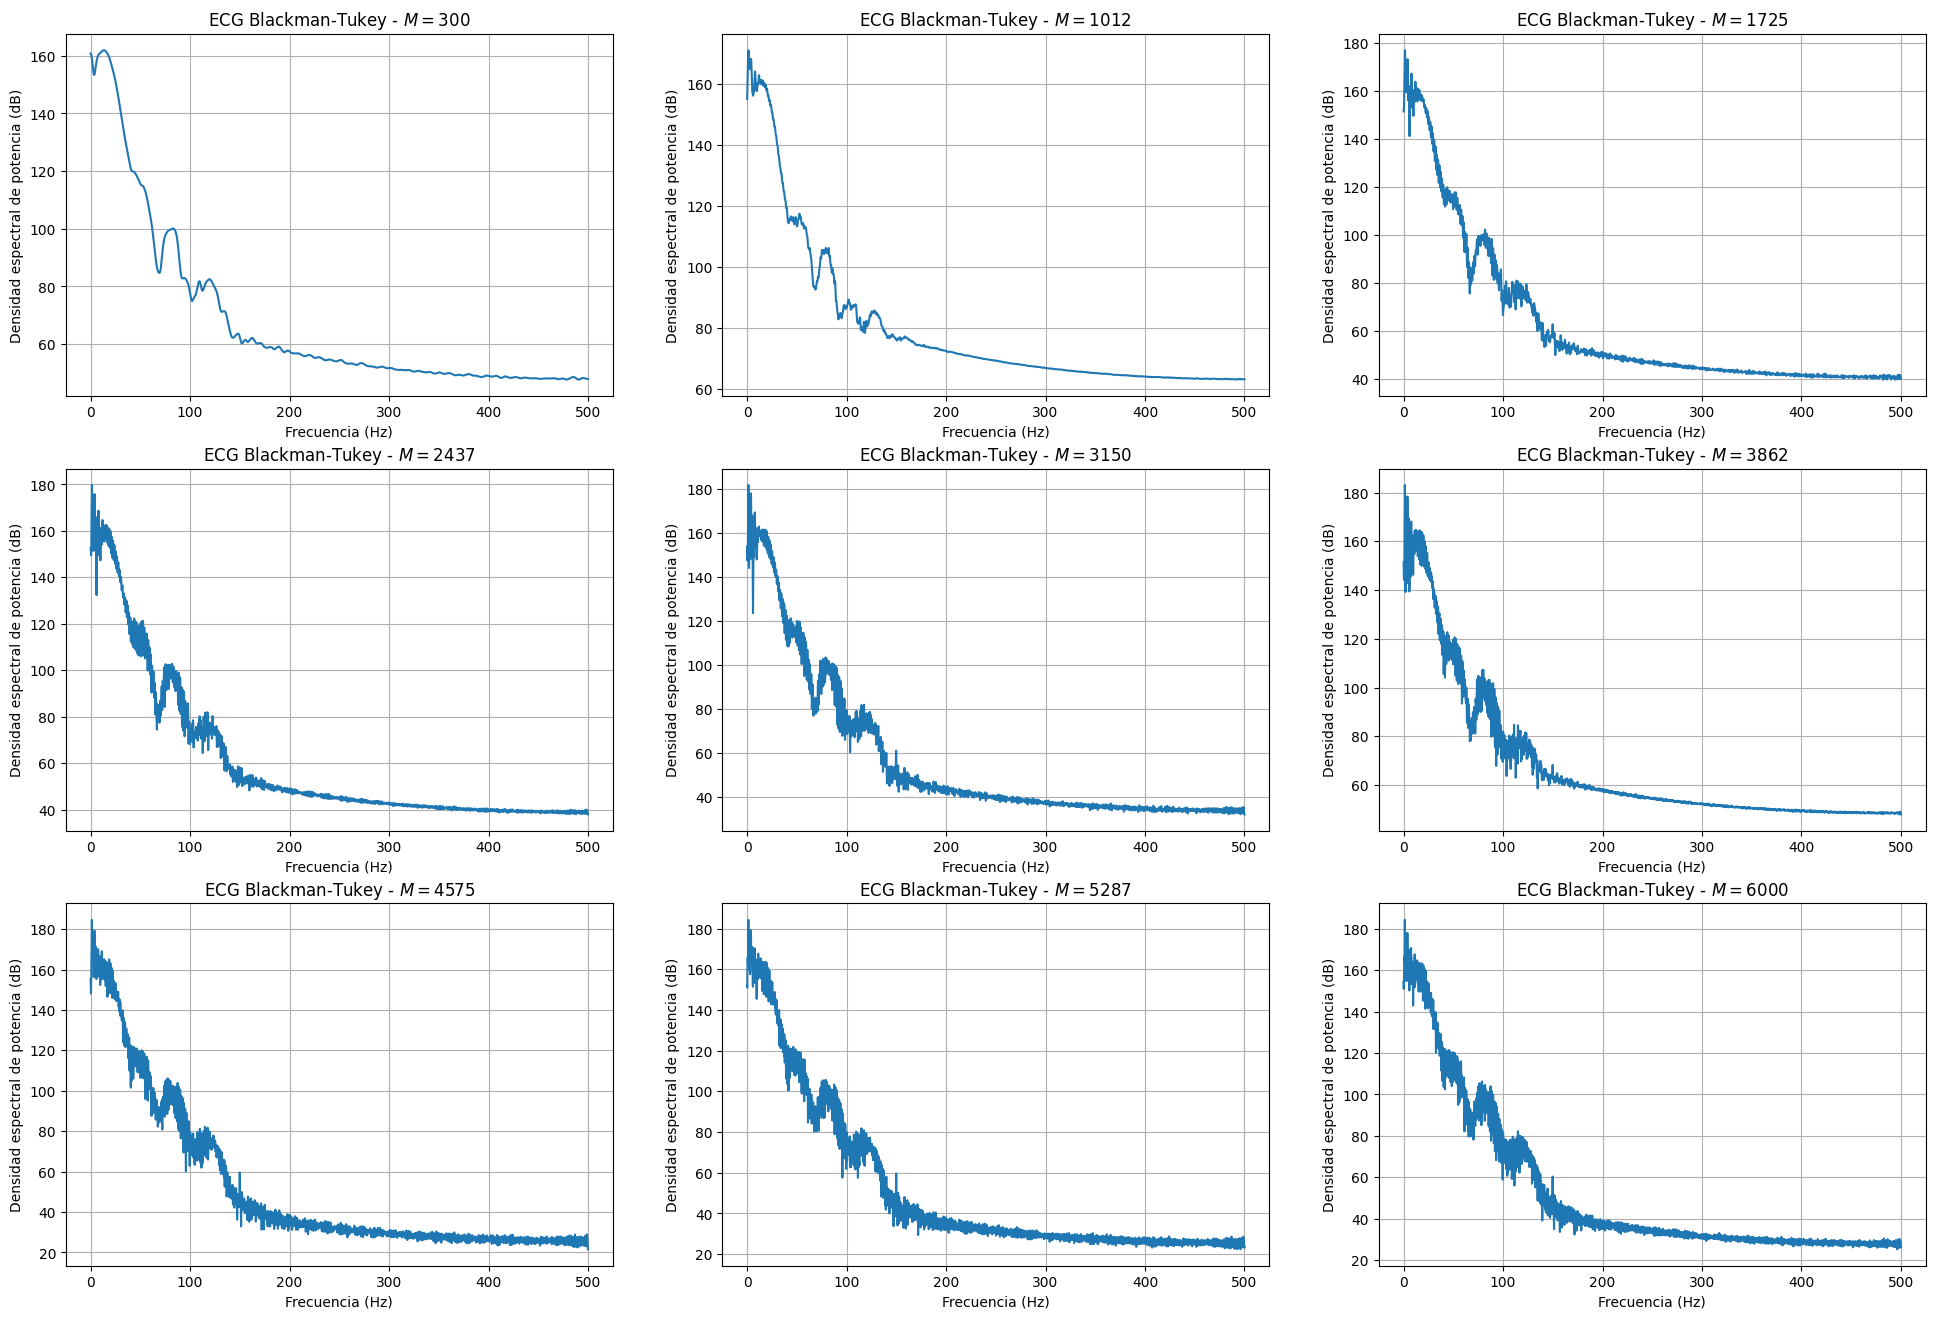

In [169]:
# Estimacion espectral mediante BLackman Tuckey



N_esg = len(ecg_one_lead)
print(f"N={N_esg}")

df = fs_ecg/N_esg # resolución espectral
ff = np.linspace(0, (N_esg-1)*df, N_esg)

vector_M = np.linspace(N_esg//100, N_esg//5, 9, dtype=int)

nombres_m = [f'M={M}' for M in vector_M]
bfrec = ff <= fs_ecg/2

plt.figure(figsize=(24, 16))
for i, M in enumerate(vector_M):
    plt.subplot(3, 3, i+1)
    xx = ecg_one_lead[:N_esg].reshape(N_esg,1)
    #print(data.shape)
    xx = xx - np.mean(xx, axis=0) # centrado
    btuckey_result = blackman_tukey(xx, M=M, window='blackman')
    #print(btuckey_result.shape)
    signal_db = 10 * np.log10(np.abs(btuckey_result[bfrec,:])**2 + 1e-10)
    plt.title(fr'ECG Blackman-Tukey - $M={M}$')
    plt.plot(ff[bfrec], signal_db)
    plt.xlabel('Frecuencia (Hz)')
    plt.ylabel('Densidad espectral de potencia (dB)')
    plt.grid()


    
    
    
    
    
    